# Coding Session 09 · Lab W9
## From effects to costs and campaign choices

We will match denominators, build reusable calculations, inspect uncertainty, and update an effect estimate with new evidence. This week uses the lab's documented cost/effect inputs because the existing robocall file contains no intervention cost or contact-rate columns. The robocall file remains available unchanged for the earlier experiment and later prediction modules.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def load_data(filename):
    """Prefer a checkout; use the published repository in Colab."""
    relative = Path("wk09_cost_effectiveness") / "data" / filename
    candidates = [Path("data") / filename, relative]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path)
    return pd.read_csv("https://raw.githubusercontent.com/albertostefanelli/DSPC_coding_sessions/master/" + relative.as_posix())

## 1. Read units before dividing

These CSVs are **instructional inputs from Joshua Kalla's W9 lab**, not newly verified study-level replication data. Their source labels are part of the teaching case. The effects are percentage-point changes **per attempted contact**; the costs are per completed contact. Mail/text contact rates of 1 mean the case prices a send, not that everyone reads a message.

Source: [W9 data](https://github.com/joshuakalla/data_science_campaigns_26/tree/main/weeks/wk09_cost_effectiveness/data); version and original filenames are recorded in [data provenance](https://github.com/albertostefanelli/DSPC_coding_sessions/blob/master/wk09_cost_effectiveness/data/README.md).

In [2]:
tactics = load_data("gotv_tactics.csv")
new_study = load_data("new_canvassing_study.csv")
display(tactics)
display(new_study)

,tactic,effect_pp,effect_low_pp,effect_high_pp,cost_per_contact,contact_rate,source
0,Door-to-door canvassing,2.0,1.0,3.0,20.00,0.30,Green & Gerber meta-analysis
1,Direct mail,0.7,0.3,1.1,0.60,1.00,Gerber et al. 2017 replication
2,Phone calls,0.5,0.1,0.9,2.00,0.25,Green & Gerber meta-analysis
3,Text messages,0.1,-0.1,0.3,0.08,1.00,recent SMS studies


,tactic,effect_pp,effect_low_pp,effect_high_pp,cost_per_contact,contact_rate,source
0,Door-to-door canvassing,0.8,0.2,1.4,25.0,0.3,"New 2024 field experiment (n=107,000)"


| Calculation | Units and meaning |
| :--- | :--- |
| cost per attempt = cost per contact × contact rate | Currency per attempt. Assumes this conversion captures all relevant costs. |
| effect proportion = effect in percentage points / 100 | Additional turnout per attempt. |
| cost per additional vote = cost per attempt / effect proportion | Currency per additional voter when the effect is positive. |
| attempts = budget / cost per attempt | Attempts affordable at constant marginal cost. |
| additional votes = attempts × effect proportion | Expected additional turnout, not guaranteed votes or net partisan votes. |

The lab asks you to write calculations for additional rows and scenarios. We demonstrate the operations with mail and phone at a different practice budget; you will extend them.

In [3]:
practice = tactics.loc[tactics["tactic"].isin(["Direct mail", "Phone calls"])].copy()
practice["cost_per_attempt"] = practice["cost_per_contact"] * practice["contact_rate"]
practice["effect_proportion"] = practice["effect_pp"] / 100
practice["cost_per_vote"] = practice["cost_per_attempt"] / practice["effect_proportion"]
practice_budget = 120_000
practice["attempts"] = practice_budget / practice["cost_per_attempt"]
practice["additional_votes"] = practice["attempts"] * practice["effect_proportion"]
display(practice[["tactic", "cost_per_attempt", "cost_per_vote", "attempts", "additional_votes"]].round(2))

,tactic,cost_per_attempt,cost_per_vote,attempts,additional_votes
1,Direct mail,0.6,85.71,200000.0,1400.0
2,Phone calls,0.5,100.00,240000.0,1200.0


**Your code:** Write the same calculation for one remaining tactic, using the row's own effect, cost, and contact rate. Then calculate the new study's cost per vote using **its** cost rather than carrying forward the older cost. Show units beside your result.

## 2. Put repeated logic in a function

The function below returns a dictionary: inputs stay visible beside results. It rejects impossible contact rates and uses a missing value when a positive-vote price is undefined. A nonpositive turnout effect can still produce a negative or zero expected-vote result; a negative price is not a bargain.

In [4]:
def campaign_scenario(effect_pp, cost_per_contact, contact_rate, budget):
    if not 0 < contact_rate <= 1 or cost_per_contact <= 0 or budget < 0:
        raise ValueError("Check the contact rate, cost, and budget.")
    cost_attempt = cost_per_contact * contact_rate
    attempts = budget / cost_attempt
    effect = effect_pp / 100
    return {"effect_pp": effect_pp, "cost_per_attempt": cost_attempt,
            "attempts": attempts, "additional_votes": attempts * effect,
            "cost_per_positive_vote": cost_attempt / effect if effect > 0 else np.nan}

phone_row = practice.loc[practice["tactic"] == "Phone calls"].iloc[0]
phone_case = campaign_scenario(phone_row["effect_pp"], phone_row["cost_per_contact"],
                               phone_row["contact_rate"], practice_budget)
pd.Series(phone_case)

effect_pp                      0.5
cost_per_attempt               0.5
attempts                  240000.0
additional_votes            1200.0
cost_per_positive_vote       100.0
dtype: float64

**Check:** Double only the budget. Which returned quantities should double and which should stay constant? This linear model assumes no saturation, no fixed setup costs, constant contact rates, and no interactions across tactics. Those assumptions can fail when scaling a campaign.

## 3. Read effect uncertainty before quoting a price

For a strictly positive effect interval, a higher effect gives a lower price, so the interval endpoints reverse. If an interval reaches zero or negative effects, there is no ordinary finite interval for the cost of a positive additional vote. Show the effect range and expected-vote range instead of hiding this behind a negative price.

,tactic,effect_low_pp,effect_high_pp,votes_at_low_effect,votes_at_high_effect,price_low,price_high,price_interval
0,Door-to-door canvassing,1.0,3.0,200.0,600.0,200.00,600.0,"finite, holding unit cost/contact rate fixed"
1,Direct mail,0.3,1.1,600.0,2200.0,54.55,200.0,"finite, holding unit cost/contact rate fixed"
2,Phone calls,0.1,0.9,240.0,2160.0,55.56,500.0,"finite, holding unit cost/contact rate fixed"
3,Text messages,-0.1,0.3,-1500.0,4500.0,NaN,NaN,crosses zero: no finite positive-vote interval


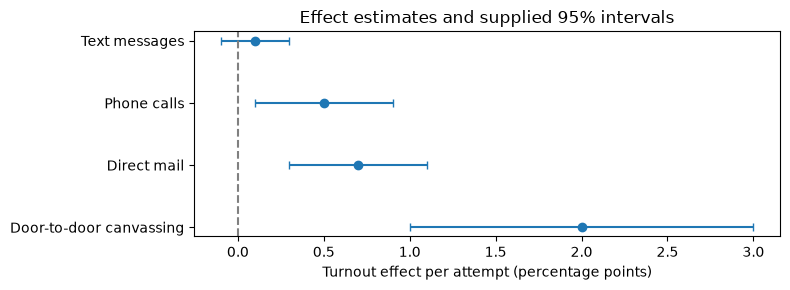

In [5]:
def uncertainty_scenario(row, budget):
    cost_attempt = row["cost_per_contact"] * row["contact_rate"]
    low, high = row["effect_low_pp"] / 100, row["effect_high_pp"] / 100
    attempts = budget / cost_attempt
    positive_interval = low > 0
    return {"tactic": row["tactic"], "effect_low_pp": 100 * low,
            "effect_high_pp": 100 * high,
            "votes_at_low_effect": attempts * low, "votes_at_high_effect": attempts * high,
            "price_low": cost_attempt / high if positive_interval else np.nan,
            "price_high": cost_attempt / low if positive_interval else np.nan,
            "price_interval": "finite, holding unit cost/contact rate fixed" if positive_interval
                              else "crosses zero: no finite positive-vote interval"}

uncertainty = pd.DataFrame([uncertainty_scenario(row, practice_budget)
                            for _, row in tactics.iterrows()])
display(uncertainty.round(2))
fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(tactics["effect_pp"], tactics["tactic"],
            xerr=np.vstack([tactics["effect_pp"] - tactics["effect_low_pp"],
                            tactics["effect_high_pp"] - tactics["effect_pp"]]), fmt="o", capsize=3)
ax.axvline(0, color="gray", linestyle="--")
ax.set(xlabel="Turnout effect per attempt (percentage points)", title="Effect estimates and supplied 95% intervals")
plt.tight_layout()
plt.show()

**Interpret:** The chart orders tactics by neither budget impact nor certainty. Which row's price is undefined over part of its effect range? What cost or capacity information would you need before recommending an allocation?

## 4. Updating is a weighted mean with assumptions

A symmetric approximate 95% interval supplies a standard error: interval width divided by `2 × 1.96`. Precision is `1 / SE**2`. The supplied function combines a normal prior with an independent normal likelihood describing the **same underlying effect**. It is not automatically justified when studies differ in population, implementation, or outcome; relevance and between-study variation matter.

We demonstrate with explicitly hypothetical estimates. Apply the same sequence to the lab's prior and new study yourself; do not mistake the practice numbers for empirical findings.

In [6]:
def update_normal(prior_mean, prior_se, new_mean, new_se):
    if prior_se <= 0 or new_se <= 0:
        raise ValueError("Standard errors must be positive.")
    prior_precision, new_precision = 1 / prior_se**2, 1 / new_se**2
    total = prior_precision + new_precision
    return pd.Series({
        "updated_effect_pp": (prior_precision * prior_mean + new_precision * new_mean) / total,
        "updated_se_pp": np.sqrt(1 / total),
        "new_study_weight": new_precision / total,
    })
# Hypothetical teaching example, all effects and SEs in percentage points.
example = update_normal(prior_mean=1.5, prior_se=0.5, new_mean=0.5, new_se=0.25)
display(example)
np.testing.assert_allclose(example["updated_effect_pp"], 0.7)

updated_effect_pp    0.700000
updated_se_pp        0.223607
new_study_weight     0.800000
dtype: float64

**Your code:** Read the new study's interval and recover its standard error. Recover the older canvassing standard error from the corresponding `tactics` row. Print each precision and its normalized weight before calculating the updated mean. Explain why one precise study can receive more weight than a noisy summary of many studies, and when this calculation would give false confidence.

## Further practice: make the decision calculation explicit

1. Write a loop or a short table that runs mail and new-study canvassing under a practice budget of 200,000 currency units. Show attempts and additional turnout separately.
2. Hold the new study's cost fixed and compare the old, new, and updated effect assumptions. Then change the contact rate and state which cost assumption you are holding fixed.
3. Additional turnout is not net partisan gain. In a **hypothetical** group splitting 55/45 between two candidates, 100 additional voters yield a net margin gain of 10. Write that conversion and explain why a common multiplier across tactics may be implausible.
4. Give one reason that the cheapest estimated turnout could be infeasible at scale. Use an effect range, not just a point estimate, to explain uncertainty.

Keep the lab's full donor memo as your own assignment. Restart the runtime, run the demonstrations in order, and inspect the tables and figure before interpreting your practice.